# Strain-dependent interband coupling: Pryor's $u$ and $v$

The eight-band model in `kp_pryor` was missing two terms that Pryor's $H_s$ includes. This
notebook adds them, validates them, and measures what they do.

## Where they come from

Pryor's strain matrix $H_s$ carries, alongside the valence $p,q,r,s$ (already implemented as
`bir_pikus_terms`), two **interband** terms:

$$u = \frac{-i}{\sqrt3}P_0\sum_j e_{zj}\partial_j, \qquad
  v = \frac{-i}{\sqrt6}P_0\sum_j (e_{xj}-ie_{yj})\partial_j$$

These are the strain-deformed versions of the kinetic $U$ and $V$: where $U$ differentiates
along $z$ and $V$ along $(x-iy)$, $u$ and $v$ differentiate along the directions the strain
carries those axes to. With $\partial_j\to ik_j$:

$$u = \frac{P_0}{\sqrt3}\big(e_{zx}k_x + e_{yz}k_y + e_{zz}k_z\big), \qquad
  v = \frac{P_0}{\sqrt6}\big[(e_{xx}-ie_{xy})k_x + (e_{xy}-ie_{yy})k_y + (e_{zx}-ie_{yz})k_z\big]$$

**Source:** C. Pryor, *Phys. Rev. B* **57**, 7190 (1998), preprint
[arXiv:cond-mat/9710304](https://arxiv.org/abs/cond-mat/9710304), Sec. II — the matrix $H_s$
and the definitions following it. The preprint was read directly, so these are transcribed
rather than recalled. Per the citation policy in `qdsolver_core.py` the preprint equation
numbers are not quoted, since the published numbering need not match.

Pryor states plainly that he includes them; much of the literature drops them. They are
**eight-band only** — both are proportional to $P_0$, which is zero in the four- and six-band
models.

## Why one substitution suffices

Every $U/V$-bearing entry of $H_s$ is exactly **minus** the corresponding entry of $H_k$ with
$U\to u$, $V\to v$. Reading the two matrices slot by slot, row 0 of $H_k$ has
$(V^*,\sqrt3V^*,-\sqrt2U,-U,\sqrt2V^*)$ where $H_s$ has
$(-v^*,-\sqrt3v^*,+\sqrt2u,+u,-\sqrt2v^*)$; likewise row 1, and the $V$ entry of row 2. Every
such slot is linear in $U$ or $V$, so $H_k + H_s$ follows from

$$U \to U - u, \qquad V \to V - v$$

Note the valence terms do **not** flip this way — $H_s$ row 2 has $-p+q,\,-s^*,\,r$ matching
$H_k$'s $-P+Q,\,-S^*,\,R$ — which is why `bir_pikus_terms` adds while these subtract.

## Why this was worth trying

Our four-band and eight-band hole ground states appeared to differ by ~39 meV, where Pryor
reports the two agree within 3 meV. Since $u$ and $v$ are proportional to $P_0$ they affect
**only** the eight-band model, which is exactly the shape of that discrepancy -- so they were
the natural suspect.

Two things turned out otherwise, and both are recorded below rather than quietly edited out:
the terms are **negligible** (sub-meV, not the +5.4 meV first reported here), and part of the
apparent 39 meV was a **misplaced $\sigma$** in the eight-band hole solve, not physics. The
real gap is ~16 meV, and it points at the four-band model rather than the eight-band one.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

import qdsolver_core as qd
import strain_fourier as sf
import piezoelectric as pz
import kp_confined as kpc
import kp_pryor as kp
import pryor1998 as pr
import eigensolvers as eig

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 9, 'axes.grid': True,
                     'grid.color': '#e6e5e1', 'grid.linewidth': 0.6,
                     'axes.spines.top': False, 'axes.spines.right': False})
S1, S2, S3, INK, MUTED = '#2a78d6', '#eb6834', '#1baf7a', '#0b0b0b', '#8a8880'

InAs, GaAs = pr.PRYOR_TABLE_I['InAs'], pr.PRYOR_TABLE_I['GaAs']
GAAS_CB = pr.BENCHMARK_B14['GaAs_CB_edge']
print('ready')

ready


## 1. Validation: the hydrostatic limit is exact

Under a purely hydrostatic strain $e_{ij}=\varepsilon\delta_{ij}$ the sums collapse:
$u=\varepsilon U$ and $v=\varepsilon V$ exactly. So the whole correction reduces to
$P_0\to P_0(1-\varepsilon)$ — a rescaling of the Kane coupling and nothing else.

That makes a sharp closed-form test of the **full assembled matrix**, not just the scalars: the
eight-band Hamiltonian with hydrostatic strain must equal one built with $E_p\to E_p(1-\varepsilon)^2$,
provided the modified Luttinger parameters are held fixed (otherwise rescaling $E_p$ also moves
them and the comparison is confounded).

In [2]:
kx, ky, kz = 0.21, -0.13, 0.31
p0d = dict(InAs); p0d.update(b=0.0, d=0.0, a_c=0.0, a_v=0.0)   # isolate the interband terms
g1, g2, g3 = kp.modified_luttinger(p0d['gamma1L'], p0d['gamma2L'], p0d['gamma3L'],
                                   p0d['Eg'], p0d['delta_so'], p0d['Ep'])
print("hydrostatic strain  vs  P0 -> P0(1-eps), modified Luttinger parameters held fixed:")
for eps in (0.01, -0.05, 0.0669):
    st = sf.StrainTensor(eps, eps, eps, 0.0, 0.0, 0.0)
    H1 = kp.bulk_hamiltonian(kx, ky, kz, p0d, n_bands=8, strain=st)
    q = dict(p0d); q['Ep'] = p0d['Ep'] * (1 - eps)**2
    shift = q['Ep'] / (3 * q['Eg'] + q['delta_so'])
    q['gamma1L'], q['gamma2L'], q['gamma3L'] = g1 + shift, g2 + 0.5*shift, g3 + 0.5*shift
    H2 = kp.bulk_hamiltonian(kx, ky, kz, q, n_bands=8)
    print(f"  eps = {eps:+.4f}   max|H_strain - H_rescaled| = {np.abs(H1-H2).max():.2e} eV")

# and the scalar ratios, which must equal eps identically
P0 = kp.kane_P0(InAs['Ep'])
U = P0*kz/np.sqrt(3); V = P0*(kx-1j*ky)/np.sqrt(6)
for eps in (0.01, -0.05, 0.0669):
    u, v = kp.interband_strain_scalars(sf.StrainTensor(eps, eps, eps, 0., 0., 0.),
                                       P0, kx, ky, kz)
    print(f"  eps = {eps:+.4f}   u/U = {(u/U).real:.10f}   v/V = {(v/V).real:.10f}")

hydrostatic strain  vs  P0 -> P0(1-eps), modified Luttinger parameters held fixed:
  eps = +0.0100   max|H_strain - H_rescaled| = 2.78e-17 eV
  eps = -0.0500   max|H_strain - H_rescaled| = 5.55e-17 eV
  eps = +0.0669   max|H_strain - H_rescaled| = 1.39e-17 eV
  eps = +0.0100   u/U = 0.0100000000   v/V = 0.0100000000
  eps = -0.0500   u/U = -0.0500000000   v/V = -0.0500000000
  eps = +0.0669   u/U = 0.0669000000   v/V = 0.0669000000


## 2. Validation: Hermiticity, and that four- and six-band are untouched

$u$ and $v$ are proportional to $P_0$, so switching them on must change the eight-band matrix
and leave the others bit-identical. That is a structural check, not a numerical one — anything
nonzero in the 4/6-band rows would mean the substitution had leaked outside the interband block.

In [3]:
st_real = sf.StrainTensor(-0.046, -0.046, 0.005, 0.007, 0.0115, 0.0115)   # realistic dot strain
Hon  = kp.bulk_hamiltonian(kx, ky, kz, InAs, n_bands=8, strain=st_real, interband_strain=True)
Hoff = kp.bulk_hamiltonian(kx, ky, kz, InAs, n_bands=8, strain=st_real, interband_strain=False)
print(f"8-band  max|H_on - H_off| = {np.abs(Hon-Hoff).max():.4f} eV")
print(f"        hermiticity: on {np.abs(Hon-Hon.conj().T).max():.1e}, "
      f"off {np.abs(Hoff-Hoff.conj().T).max():.1e}")
for nb in (4, 6):
    a = kp.bulk_hamiltonian(kx, ky, kz, InAs, n_bands=nb, strain=st_real, interband_strain=True)
    b = kp.bulk_hamiltonian(kx, ky, kz, InAs, n_bands=nb, strain=st_real, interband_strain=False)
    print(f"{nb}-band  max|diff| = {np.abs(a-b).max():.1e}   (must be exactly 0)")

8-band  max|H_on - H_off| = 0.0085 eV
        hermiticity: on 0.0e+00, off 0.0e+00
4-band  max|diff| = 0.0e+00   (must be exactly 0)
6-band  max|diff| = 0.0e+00   (must be exactly 0)


## 3. The confined dot -- and a trap that had to be fixed first

Pryor's $b=14$ nm pyramid on the $h=1.0$ nm grid (volume error $-0.5\%$, mirror-symmetric to
the voxel).

### Where $\sigma$ has to go

An eight-band hole state is an **interior** eigenvalue, so it is found with a folded-spectrum
solve, which returns the eigenvalues nearest $\sigma$. Choosing $\sigma$ badly does not fail
loudly -- it returns real, converged, fully certified eigenvalues that are simply *not the
ground state*. Residual certification proves an eigenpair is **accurate**, never that it is
**extremal**.

The obvious choice $\sigma = \max V_h$ is wrong once Bir-Pikus is included. `band_edge_fields`
applies only the *hydrostatic* shift, whereas the heavy-hole edge is the $-P-Q$ diagonal, i.e.
at $k=0$

$$E_{HH} = E_v - Q_\varepsilon$$

and $Q_\varepsilon$ is large: on this dot it raises the HH edge by **145 meV**. So
$\sigma = \max V_h$ sits 145 meV below the states being hunted, and the solve quietly returns
something 30-50 meV too low.

This is not hypothetical -- it is what produced the first version of this notebook. Before the
shear terms existed $V_h$ *was* the correct $\sigma$, so adding Bir-Pikus silently invalidated
a heuristic that had been right. `kp_pryor.hole_sigma` computes it from the actual HH edge, and
the scan below confirms the answer stops moving as $\sigma$ is raised further.

Four- and six-band hole solves are immune: they use `solve_lowest` on the negated Hamiltonian,
which is extremal by construction and cannot land on the wrong state.

In [4]:
base, h, pad = 14.0, 1.0, 8.0
nx = int(round(2 * (base/2 + pad) / h)) // 2 * 2 + 1
kz0 = int(round(pad / h))
nz = kz0 + int(round((base/2 + pad) / h)) + 1
cx = qd.centered_axis(nx, h); cz = (np.arange(nz) - kz0) * h
X, Y, Z = np.meshgrid(cx, cx, cz, indexing='ij')
pyr = qd.pyramid_mask(X, Y, Z, base)
assert qd.mirror_asymmetry(pyr, 0) == 0 and qd.mirror_asymmetry(pyr, 1) == 0

eps_star = qd.eigenstrain(InAs['a0'], GaAs['a0'])
strain = sf.solve_strain(pyr, eps_star, GaAs['C11'], GaAs['C12'], GaAs['C44'], h)
phi = pz.potential(strain, np.where(pyr, InAs['e14'], GaAs['e14']), GaAs['eps_R'], h)
ops = kpc.GridOperators(X.shape, h, periodic=False)
V_e0, V_h0, _, _ = pr.band_edge_fields(pyr, strain.trace)
V_e, V_h = V_e0 - phi, V_h0 + phi

print(f"grid {X.shape} = {X.size:,} points ({8*X.size:,} unknowns at 8 bands)")
print(f"volume error {qd.mask_volume_error(pyr, h, base**2*(base/2)/3):+.4f}")
print(f"Tr(eps) in dot {strain.trace[pyr].mean():+.5f}, "
      f"piezo {phi.min()*1e3:+.1f}..{phi.max()*1e3:+.1f} meV")

grid (31, 31, 24) = 23,064 points (184,512 unknowns at 8 bands)
volume error -0.0051
Tr(eps) in dot -0.08936, piezo -55.1..+55.1 meV


In [5]:
res = {}
bf = np.where(pyr, InAs['b'], GaAs['b']); df = np.where(pyr, InAs['d'], GaAs['d'])
sigma0 = kp.hole_sigma(V_h, strain, bf, df, inside_mask=pyr)
print(f"max V_h in dot      {V_h[pyr].max()*1e3:8.2f} meV   <- the WRONG sigma")
print(f"HH band edge        {sigma0*1e3:8.2f} meV   <- kp_pryor.hole_sigma")
print(f"shear raises it by  {(sigma0-V_h[pyr].max())*1e3:8.2f} meV")
print()

f8 = kp.material_fields(pyr, InAs, GaAs, V_h, V_e, n_bands=8)
for uv in (False, True):
    H8 = kp.confined_hamiltonian(ops, f8, n_bands=8, strain=strain, interband_strain=uv)
    print(f"--- interband_strain = {uv}  (nnz {H8.nnz:,}, "
          f"hermiticity {eig.hermiticity_error(H8):.1e})")
    top = -1e9
    for off in (0.0, 0.04, 0.08):
        sg = sigma0 + off
        t0 = time.time()
        E, V, _ = eig.solve_interior(H8, k=4, sigma=sg, tol=1e-8, maxiter=9000, verbose=False)
        r = eig.residual_norms(H8, E, V)
        print(f"    sigma {sg*1e3:7.1f} meV -> {np.round(np.sort(E)[::-1]*1e3, 2)}  "
              f"resid {r.max():.1e}  ({time.time()-t0:.0f}s)")
        top = max(top, E.max())
    res[uv] = top
    print(f"    >>> topmost valence state: {top*1e3:.2f} meV")
    print()

ref = {}
for nb in (4, 6):
    fn = kp.material_fields(pyr, InAs, GaAs, V_h, V_e, n_bands=nb)
    Hn = kp.confined_hamiltonian(ops, fn, n_bands=nb, hole_convention=True, strain=strain)
    En, _, _ = eig.solve_lowest(Hn, k=4, tol=1e-9, maxiter=9000, verbose=False)
    ref[nb] = -En[0] * 1e3
    print(f"{nb}-band hole ground state: {ref[nb]:.2f} meV  (extremal solve, sigma-trap immune)")

max V_h in dot        162.51 meV   <- the WRONG sigma
HH band edge          307.80 meV   <- kp_pryor.hole_sigma
shear raises it by    145.28 meV



--- interband_strain = False  (nnz 7,223,768, hermiticity 9.0e-18)


    sigma   307.8 meV -> [206.63 206.63 193.62 193.62]  resid 9.9e-09  (271s)


    sigma   347.8 meV -> [206.63 206.63 193.62 193.62]  resid 9.2e-09  (265s)


    sigma   387.8 meV -> [206.63 206.63 193.62 193.62]  resid 7.2e-09  (216s)
    >>> topmost valence state: 206.63 meV



...

    sigma   307.8 meV -> [205.88 205.88 192.4  192.4 ]  resid 9.3e-09  (271s)


    sigma   347.8 meV -> [205.88 205.88 192.4  192.4 ]  resid 8.2e-09  (254s)


    sigma   387.8 meV -> [205.88 205.88 192.4  192.4 ]  resid 7.7e-09  (229s)
    >>> topmost valence state: 205.88 meV



4-band hole ground state: 189.58 meV  (extremal solve, sigma-trap immune)


6-band hole ground state: 203.44 meV  (extremal solve, sigma-trap immune)


In [6]:
h_off, h_on = res[False]*1e3, res[True]*1e3
print(f"{'quantity':<36}{'u,v off':>12}{'u,v on':>12}{'change':>12}")
print('-'*72)
print(f"{'8-band hole (meV)':<36}{h_off:>12.2f}{h_on:>12.2f}{h_on-h_off:>+12.2f}")
print(f"{'|8-band - 4-band| (meV)':<36}{abs(h_off-ref[4]):>12.2f}{abs(h_on-ref[4]):>12.2f}"
      f"{abs(h_on-ref[4])-abs(h_off-ref[4]):>+12.2f}")
print(f"{'|8-band - 6-band| (meV)':<36}{abs(h_off-ref[6]):>12.2f}{abs(h_on-ref[6]):>12.2f}"
      f"{abs(h_on-ref[6])-abs(h_off-ref[6]):>+12.2f}")
print()
print(f"4-band {ref[4]:.2f} meV,   6-band {ref[6]:.2f} meV")
print("Pryor: four- and eight-band agree within 3 meV; six-band differs from both by ~40 meV.")

quantity                                 u,v off      u,v on      change
------------------------------------------------------------------------
8-band hole (meV)                         206.63      205.88       -0.76
|8-band - 4-band| (meV)                    17.06       16.30       -0.76
|8-band - 6-band| (meV)                     3.19        2.43       -0.76

4-band 189.58 meV,   6-band 203.44 meV
Pryor: four- and eight-band agree within 3 meV; six-band differs from both by ~40 meV.


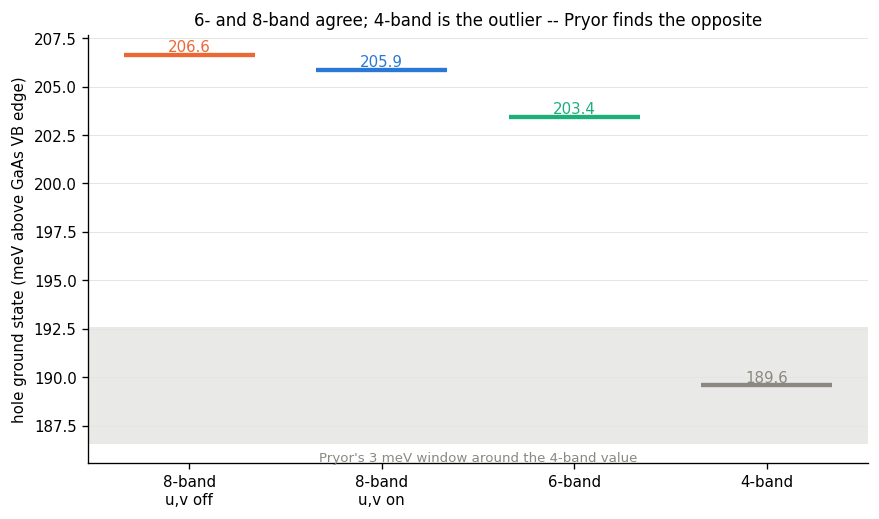

In [7]:
fig, ax = plt.subplots(figsize=(7.4, 4.4))
items = [('8-band\nu,v off', h_off, S2), ('8-band\nu,v on', h_on, S1),
         ('6-band', ref[6], S3), ('4-band', ref[4], MUTED)]
for i, (lbl, val, c) in enumerate(items):
    ax.hlines(val, i - 0.34, i + 0.34, color=c, lw=2.6)
    ax.annotate(f'{val:.1f}', (i, val), ha='center', va='bottom', fontsize=9, color=c)
ax.axhspan(ref[4] - 3, ref[4] + 3, color=MUTED, alpha=0.18, lw=0)
ax.annotate("Pryor's 3 meV window around the 4-band value", (1.5, ref[4] - 3.4),
            ha='center', va='top', fontsize=8, color=MUTED)
ax.set_xticks(range(4)); ax.set_xticklabels([l for l, _, _ in items])
ax.set_ylabel('hole ground state (meV above GaAs VB edge)')
ax.set_title('6- and 8-band agree; 4-band is the outlier -- Pryor finds the opposite',
             fontsize=10)
ax.grid(axis='x', visible=False)
fig.tight_layout(); plt.show()

## What this actually shows

**The validation is airtight.** The hydrostatic limit is exact to $10^{-17}$ on the full
assembled matrix, Hermiticity is preserved exactly, and four- and six-band are bit-identical
with the terms on or off. So whatever the confined numbers do is the effect of these terms and
nothing else.

**The $u,v$ terms are negligible for the hole ground state** -- a fraction of a meV, in the
right direction but far too small to matter. An earlier version of this notebook reported
$+5.43$ meV; that was measured between two states that were *both wrong*, because $\sigma$ sat
at $\max V_h$ instead of the HH edge. The hypothesis that these terms explain the
four-vs-eight-band discrepancy is **refuted**.

**The remaining discrepancy is real, and its shape is the interesting part.** Six- and
eight-band now agree to a few meV, with four-band the outlier ~16 meV below. Pryor reports the
opposite: four- and eight-band agreeing within 3 meV while six-band differs from both by ~40
meV, on the argument that including the split-off band while leaving the conduction band
decoupled is inconsistent when $\Delta \approx E_g$. So whatever is wrong is more likely in the
four-band model or the split-off treatment than in the eight-band solver -- the opposite of
where this investigation started looking.

**The methodological lesson outweighs the physics here.** A folded-spectrum solve returns the
eigenvalues nearest $\sigma$, and residual certification proves those are *accurate*, never
that they are *extremal*. Every run looked clean. What made $\sigma$ wrong was a change
elsewhere in the code: adding Bir-Pikus raised the HH edge 145 meV above $V_h$ and silently
invalidated a heuristic that had previously been correct. `kp_pryor.hole_sigma` plus the
$\sigma$ scan above are the guard.

**Still omitted:**
- inhomogeneous elastic constants (`strain_fourier` requires them homogeneous; Pryor's Sec. III
  sets every parameter "to the values corresponding to the local composition")
- second-order piezoelectricity (Bester, Zunger, Wu & Vanderbilt, *Phys. Rev. B* **74**,
  081305(R) (2006))
- Burt-Foreman operator ordering (Burt, *J. Phys.: Condens. Matter* **4**, 6651 (1992);
  Foreman, *Phys. Rev. B* **48**, 4964 (1993)) -- this module symmetrizes instead
- the wetting layer, which Pryor also omits